# Checkerboard CDW: analysis of the Monte Carlo data

Half-filled square-lattice Coulomb gas with nearest-neighbour repulsion $V_1=1$ on an $L\times L$ torus ($L=32$, $N=512$),
across the checkerboard ordering transition.  Data: `data/G<Gamma>.pt` produced by `generate_cdw.py` (one file per
$\Gamma = 1/T$, exact energies).  Model and Ewald kernel: `lattice_cdw.py`; regression and second-moment diagnostics: `learn.py`.

For every temperature this notebook computes

* the order parameter $\langle|\hat\rho_{(\pi,\pi)}|\rangle/N$, the defect density (occupied nearest-neighbour pairs) and $\langle S(\mathbf k)\rangle$;
* the second-moment spectrum of the regression columns $X_{b,s} = \frac{1}{2N_s^2}\sum_{\mathbf k\in s}|\hat\rho_{\mathbf k}|^2$ (one column per $D_4$ orbit $s$);
* the closed-form kernel reconstruction $E_b = \sum_s X_{b,s}\lambda_s + c$ with exact energies and with $10^{-3}$, $10^{-2}$ relative label noise, its normalised training and validation errors of the energy (RMS residual divided by the standard deviation of the training energies), and jackknife errors over four groups of chains.

Results go to `results/analysis.pt`; the data behind the main-text panels are exported to `Results_2D/Experiment_3/CDW_data/`.

In [1]:
import os, sys, math, torch, numpy as np
import matplotlib.pyplot as plt
HERE = os.getcwd(); ROOT = os.path.dirname(HERE)
sys.path.insert(0, ROOT)
from checkerboard.lattice_cdw import LatticeCDW
from checkerboard.learn import OrbitBasis, fit_kernel, align, second_moment, effective_rank, jackknife
torch.set_default_dtype(torch.float64)

DATA, RES = os.path.join(HERE, "data"), os.path.join(HERE, "results"); os.makedirs(RES, exist_ok=True)
EXPORT = os.path.join(ROOT, "Results_2D", "Experiment_3", "CDW_data")
L, V1 = 32, 1.0; NOISE = (1e-3, 1e-2); N_VAL_CHAINS = 4

sim = LatticeCDW(L, V1, 1.0); rb = OrbitBasis(L)
lam_true = align(rb.project(sim.lam), rb.mult); K_true = rb.kernel(lam_true)
runs = {}
for f in os.listdir(DATA):
    if f.startswith("G") and f.endswith(".pt"):
        d = torch.load(os.path.join(DATA, f), weights_only=False); runs[d["Gamma"]] = d
runs = dict(sorted(runs.items()))
print(f"L={L}, N={sim.N}, V1={V1}: {rb.n_par} orbits, {rb.n_par - 2} regression unknowns; temperatures:", [round(1 / G, 3) for G in runs])

L=32, N=512, V1=1.0: 153 orbits, 151 regression unknowns; temperatures: [2.0, 1.25, 1.053, 1.0, 0.833, 0.714, 0.625, 0.5, 0.4, 0.357, 0.333, 0.312, 0.286, 0.281, 0.2, 0.1]


## Per-temperature analysis

The first quarter of every chain is discarded as equilibration.  The last `N_VAL_CHAINS` chains are the validation set; the rest form the training set.

In [2]:
summary, fits, S_maps, snaps, sv_all = {}, {}, {}, {}, {}
for G, d in runs.items():
    pos = d["pos"].long(); T0 = pos.shape[0]; pos, E = pos[T0 // 4:], d["E"][T0 // 4:]; T, C = pos.shape[:2]
    sub = pos[::5].reshape(-1, sim.N, 2)                                                  # thinned set for structure factors
    mQ = torch.fft.fft2(sim.density(sub))[:, L // 2, L // 2].abs() / sim.N
    n_nn = sim.n_neighbour_pairs(sub) / sim.N
    S_maps[G] = rb.mean_structure_factor(sub, sim); snaps[G] = sim.density(pos[-1, :1])[0]
    Ct = C - N_VAL_CHAINS
    X = rb.design(pos[:, :Ct].reshape(-1, sim.N, 2), sim); y = E[:, :Ct].reshape(-1)
    X_va = rb.design(pos[:, Ct:].reshape(-1, sim.N, 2), sim); y_va = E[:, Ct:].reshape(-1)
    sv = second_moment(X); sv_all[G] = sv
    out = {}; g = torch.Generator().manual_seed(int(10 * G))
    for rel in (0.0,) + NOISE:
        theta, c = fit_kernel(X, y + rel * y.std() * torch.randn(len(y), generator=g)); lam = align(theta, rb.mult)
        out[rel] = dict(lam=lam, K=rb.kernel(theta),
                        train=float(((X @ theta + c) - y).pow(2).mean().sqrt() / y.std()), val=float(((X_va @ theta + c) - y_va).pow(2).mean().sqrt() / y.std()),   # RMS residual / std of the training energies
                        err=float((lam - lam_true)[1:].abs().max() / lam_true.abs().max()))
    fits[G] = out
    # jackknife over 4 groups of training chains: rank counts, df(eps), fit errors
    groups = [list(range(k * Ct // 4, (k + 1) * Ct // 4)) for k in range(4)]
    Xg = X.view(T, Ct, -1); yg = y.view(T, Ct); jk = {k: [] for k in ("n3", "n6", "df3", "df6", "err0", "err2")}
    for k in range(4):
        keep = [c for c in range(Ct) if c not in groups[k]]
        Xs, ys = Xg[:, keep].reshape(-1, X.shape[1]), yg[:, keep].reshape(-1); evs = second_moment(Xs)
        jk["n3"].append(int((evs > 1e-3).sum())); jk["n6"].append(int((evs > 1e-6).sum()))
        jk["df3"].append(effective_rank(evs, 1e-3)); jk["df6"].append(effective_rank(evs, 1e-6))
        gg = torch.Generator().manual_seed(int(10 * G) + k)
        for rel, key in ((0.0, "err0"), (1e-2, "err2")):
            th, _ = fit_kernel(Xs, ys + rel * ys.std() * torch.randn(len(ys), generator=gg))
            jk[key].append(float((align(th, rb.mult) - lam_true)[1:].abs().max() / lam_true.abs().max()))
    summary[G] = dict(T=1.0 / G, E=float(E.mean()) / sim.N, m=float(mQ.mean()), m_std=float(mQ.std()), n_nn=float(n_nn.mean()),
                      n_ev=[int((sv > th).sum()) for th in (1e-3, 1e-6, 1e-9, 1e-12)], df=[effective_rank(sv, 1e-3), effective_rank(sv, 1e-6)],
                      jk={k: jackknife(v) for k, v in jk.items()}, E_std=float(y.std()), n_train=len(y), n_val=len(y_va))
    s = summary[G]
    print(f"T={s['T']:.3f}  E/N={s['E']:.4f}  m={s['m']:.3f}  defects/N={s['n_nn']:.1e}  rank(>1e-6)={s['n_ev'][1]:3d}/{rb.n_par - 2}  "
          f"exact: train {out[0.0]['train']:.0e} validation {out[0.0]['val']:.0e} kernel err {out[0.0]['err']:.1e};  1% noise: kernel err {out[1e-2]['err']:.1e}")
torch.save(dict(summary=summary, fits=fits, S=S_maps, snaps=snaps, sv=sv_all, lam_true=lam_true, K_true=K_true, q=rb.q, k_rep=rb.k_rep), os.path.join(RES, "analysis.pt"))

T=2.000  E/N=-0.3473  m=0.036  defects/N=8.1e-01  rank(>1e-6)=151/151  exact: train 2e-13 validation 2e-13 kernel err 3.7e-14;  1% noise: kernel err 1.8e-03


T=1.250  E/N=-0.5060  m=0.050  defects/N=7.0e-01  rank(>1e-6)=151/151  exact: train 2e-13 validation 2e-13 kernel err 8.3e-12;  1% noise: kernel err 4.7e-03


T=1.053  E/N=-0.5906  m=0.061  defects/N=6.4e-01  rank(>1e-6)=151/151  exact: train 2e-13 validation 2e-13 kernel err 5.7e-14;  1% noise: kernel err 2.4e-03


T=1.000  E/N=-0.6204  m=0.072  defects/N=6.1e-01  rank(>1e-6)=151/151  exact: train 2e-13 validation 2e-13 kernel err 7.6e-14;  1% noise: kernel err 2.3e-03


T=0.833  E/N=-0.7581  m=0.108  defects/N=5.0e-01  rank(>1e-6)=151/151  exact: train 1e-13 validation 2e-13 kernel err 8.3e-12;  1% noise: kernel err 4.5e-03


...

T=0.312  E/N=-1.3788  m=1.000  defects/N=1.5e-04  rank(>1e-6)=  1/151  exact: train 4e-13 validation 4e-13 kernel err 1.8e+01;  1% noise: kernel err 1.8e+01


T=0.286  E/N=-1.3789  m=1.000  defects/N=4.9e-05  rank(>1e-6)=  1/151  exact: train 1e-13 validation 0e+00 kernel err 1.8e+01;  1% noise: kernel err 1.8e+01


T=0.281  E/N=-1.3789  m=1.000  defects/N=3.7e-05  rank(>1e-6)=  1/151  exact: train 0e+00 validation 0e+00 kernel err 1.8e+01;  1% noise: kernel err 1.8e+01


T=0.200  E/N=-1.3790  m=1.000  defects/N=0.0e+00  rank(>1e-6)=  0/151  exact: train 1e+00 validation 1e+00 kernel err 1.0e+00;  1% noise: kernel err 1.0e+00


T=0.100  E/N=-1.3790  m=1.000  defects/N=0.0e+00  rank(>1e-6)=  0/151  exact: train nan validation nan kernel err 1.0e+00;  1% noise: kernel err 1.0e+00


## Transition temperature and defect gap

$T_c$ is taken as the temperature at which the order parameter crosses $1/2$ (log-linear interpolation).  The single-defect
energy $\Delta$ is the cost of moving one charge of the perfect checkerboard to a nearest-neighbour vacant site, evaluated
from the pair table; it sets the Arrhenius law $\propto e^{-\Delta/T}$ of the diffuse scattering below $T_c$.

In [3]:
gam = list(summary); Ts = np.array([summary[G]["T"] for G in gam]); ms = np.array([summary[G]["m"] for G in gam])
o = np.argsort(Ts); Ts_s, ms_s = Ts[o], ms[o]
i = int(np.where(ms_s < 0.5)[0][0]); t1, t0, m1, m0 = Ts_s[i], Ts_s[i - 1], ms_s[i], ms_s[i - 1]
T_c = float(np.exp(np.log(t0) + (0.5 - m0) / (m1 - m0) * (np.log(t1) - np.log(t0))))
sim0 = LatticeCDW(L, V1, 1.0); E0 = float(sim0.total_energy()[0]); p = sim0.pos.clone(); p[0, 0] = (p[0, 0] + torch.tensor([1, 0])) % L; sim0.pos = p
Delta = float(sim0.total_energy()[0]) - E0
print(f"T_c = {T_c:.3f}   (m = {m0:.3f} at T = {t0:.3f}, m = {m1:.3f} at T = {t1:.3f});   Delta = {Delta:.3f} e^2/a")

T_c = 0.702   (m = 0.899 at T = 0.625, m = 0.438 at T = 0.714);   Delta = 3.615 e^2/a


## Quick look

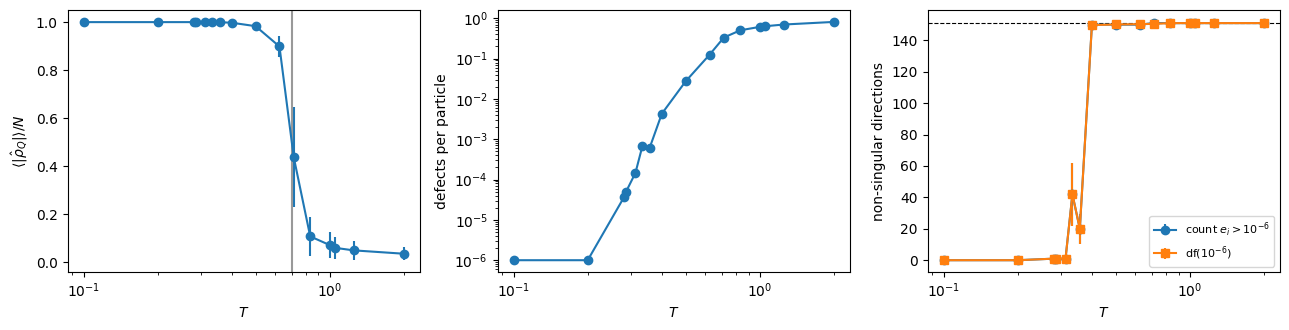

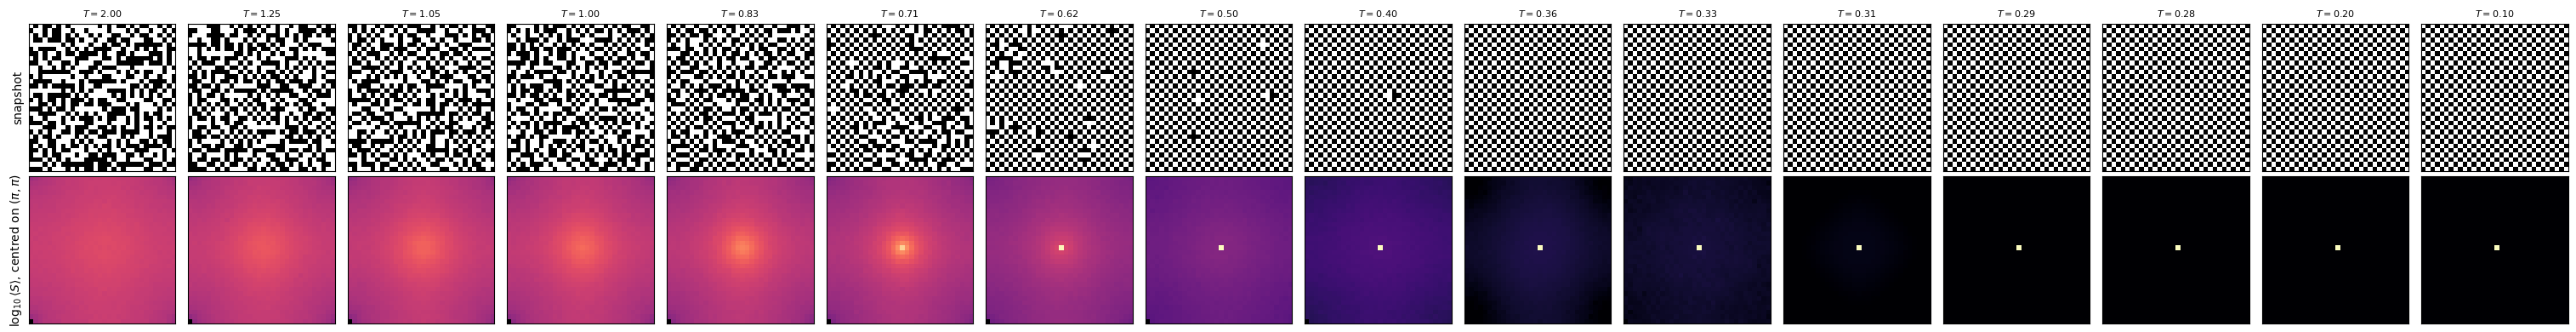

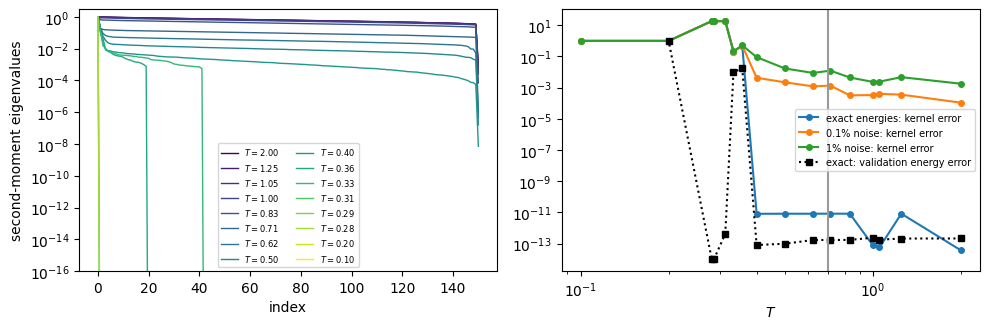

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].errorbar(Ts, ms, [summary[G]["m_std"] for G in gam], fmt="o-"); ax[0].axvline(T_c, c="0.6"); ax[0].set_ylabel(r"$\langle|\hat\rho_Q|\rangle/N$")
ax[1].semilogy(Ts, [max(summary[G]["n_nn"], 1e-6) for G in gam], "o-"); ax[1].set_ylabel("defects per particle")
ax[2].errorbar(Ts, [summary[G]["n_ev"][1] for G in gam], [summary[G]["jk"]["n6"][1] for G in gam], fmt="o-", label=r"count $e_i > 10^{-6}$")
ax[2].errorbar(Ts, [summary[G]["df"][1] for G in gam], [summary[G]["jk"]["df6"][1] for G in gam], fmt="s-", label=r"df$(10^{-6})$")
ax[2].axhline(rb.n_par - 2, ls="--", c="k", lw=0.8); ax[2].set_ylabel("non-singular directions"); ax[2].legend(fontsize=8)
for a in ax: a.set_xscale("log"); a.set_xlabel(r"$T$")
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(2, len(gam), figsize=(1.9 * len(gam), 4))
for j, G in enumerate(gam):
    ax[0, j].imshow(snaps[G].T, origin="lower", cmap="Greys", interpolation="nearest"); ax[0, j].set_title(rf"$T={summary[G]['T']:.2f}$", fontsize=8)
    Sm = np.roll(S_maps[G].numpy(), (L // 2, L // 2), (0, 1))                       # centred on (pi, pi)
    ax[1, j].imshow(np.log10(np.clip(Sm.T, 1e-4, None)), origin="lower", cmap="magma", vmin=-4, vmax=math.log10(sim.N))
    for a in ax[:, j]: a.set_xticks([]); a.set_yticks([])
ax[0, 0].set_ylabel("snapshot"); ax[1, 0].set_ylabel(r"$\log_{10}\langle S\rangle$, centred on $(\pi,\pi)$"); fig.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4)); cmap = plt.get_cmap("viridis")
for i, G in enumerate(gam): ax[0].semilogy(sv_all[G].numpy(), c=cmap(i / (len(gam) - 1)), lw=1, label=rf"$T={summary[G]['T']:.2f}$")
ax[0].set_ylim(1e-16, 3); ax[0].set_xlabel("index"); ax[0].set_ylabel("second-moment eigenvalues"); ax[0].legend(fontsize=6, ncol=2)
for rel, lab in ((0.0, "exact energies"), (1e-3, "0.1% noise"), (1e-2, "1% noise")):
    ax[1].plot(Ts, [max(fits[G][rel]["err"], 1e-14) for G in gam], "o-", ms=4, label=lab + ": kernel error")
ax[1].plot(Ts, [max(fits[G][0.0]["val"], 1e-14) for G in gam], "s:", c="k", ms=4, label="exact: validation energy error")
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].axvline(T_c, c="0.6"); ax[1].set_xlabel(r"$T$"); ax[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

## Export of the panel data (`Results_2D/Experiment_3/CDW_data`)

Plain `.npz` files, one per panel, reproducible from `cdw_panels.ipynb` without this code base:

* `snapshots.npz` — one configuration and $\langle S(\mathbf k)\rangle$ (fftshifted, $\mathbf k=0$ at the centre) above and below $T_c$;
* `weights.npz` — Bragg weight $S(\pi,\pi)/N$ and mean off-Bragg $S$ versus $T$, with $T_c$ and $\Delta$;
* `rank.npz` — second-moment eigenvalues versus $T$ (the learnable fraction is their count above a threshold);
* `reconstruction.npz` — true and learned $\lambda(\mathbf k)$ per $D_4$ orbit at the low-$T$ point, with the kernel error and the normalised training and validation errors of the energy.

In [5]:
os.makedirs(EXPORT, exist_ok=True)
G_hi = min(gam, key=lambda G: abs(1 / G - 1.5 * T_c)); G_lo = min(gam, key=lambda G: abs(1 / G - 0.45 * T_c))   # points closest to 1.5 T_c and 0.45 T_c
print(f"snapshot temperatures: T = {1 / G_hi:.3f} = {1 / G_hi / T_c:.2f} T_c and T = {1 / G_lo:.3f} = {1 / G_lo / T_c:.2f} T_c")
np.savez(os.path.join(EXPORT, "snapshots.npz"), L=L, N=sim.N, T_c=T_c,
         T_high=1 / G_hi, occ_high=snaps[G_hi].numpy(), S_high=S_maps[G_hi].numpy(),
         T_low=1 / G_lo, occ_low=snaps[G_lo].numpy(), S_low=S_maps[G_lo].numpy())
bragg = np.array([float(S_maps[G][0, 0]) / sim.N for G in gam])                            # fftshifted: (pi,pi) at index 0
diffuse = np.array([(float(S_maps[G].sum()) - float(S_maps[G][0, 0])) / (L * L - 2) for G in gam])
np.savez(os.path.join(EXPORT, "weights.npz"), T=Ts, bragg=bragg, diffuse=diffuse, order_parameter=ms, defects_per_particle=np.array([summary[G]["n_nn"] for G in gam]), T_c=T_c, Delta=Delta)
np.savez(os.path.join(EXPORT, "rank.npz"), T=Ts, eigenvalues=np.stack([sv_all[G].numpy() for G in gam]), n_unknowns=rb.n_par - 2, T_c=T_c,
         n_above_1e6=np.array([summary[G]["n_ev"][1] for G in gam]), n_above_1e6_jackknife_err=np.array([summary[G]["jk"]["n6"][1] for G in gam]))
f = fits[G_lo][0.0]
np.savez(os.path.join(EXPORT, "reconstruction.npz"), T=1 / G_lo, T_c=T_c, k_rep=rb.k_rep.numpy(), k_norm=rb.q.norm(dim=1).numpy(),
         lam_true=lam_true.numpy(), lam_learned=f["lam"].numpy(), kernel_err=f["err"], energy_err_train=f["train"], energy_err_validation=f["val"])
print("exported to", EXPORT, ":", sorted(os.listdir(EXPORT)))

snapshot temperatures: T = 1.053 = 1.50 T_c and T = 0.312 = 0.45 T_c
exported to /home/claude/work/Results_2D/Experiment_3/CDW_data : ['README.md', 'rank.npz', 'reconstruction.npz', 'snapshots.npz', 'weights.npz']
